In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pyproj import Transformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import DBSCAN

In [49]:
RANDOM_STATE = 42

PLOT_SAMPLE_SIZE = 50000
SCORE_SAMPLE_SIZE = 20000
EVAL_FEATURE_SET_SAMPLE_SIZE = 20000

K_RANGE = range(1, 21)
K_RANGE_SIL = range(2, 21)

BEST_K = None

DBSCAN_SAMPLE_SIZE = 50000
DBSCAN_EPS = None
DBSCAN_MIN_SAMPLES = None

In [50]:
df = pd.read_csv("Divar_Iran.csv", low_memory=False)

In [51]:
print(df.shape)

(995939, 61)


In [52]:
cols = [
    "price_value",
    "building_size",
    "rooms_count",
    "location_latitude",
    "location_longitude",
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "has_pool",
    "has_heating_system",
    "has_cooling_system"
]

In [53]:
df[cols].isna().sum()

price_value           429562
building_size          19515
rooms_count           153538
location_latitude     344392
location_longitude    344392
has_parking           270572
has_elevator          456402
has_warehouse         270573
has_balcony           491172
has_pool              966657
has_heating_system    627596
has_cooling_system    646328
dtype: int64

In [54]:
df_rec = df[cols].copy()

In [55]:
print(df_rec.info())
print(df_rec.isna().sum())
print(df_rec.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995939 entries, 0 to 995938
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         566377 non-null  float64
 1   building_size       976424 non-null  float64
 2   rooms_count         842401 non-null  object 
 3   location_latitude   651547 non-null  float64
 4   location_longitude  651547 non-null  float64
 5   has_parking         725367 non-null  object 
 6   has_elevator        539537 non-null  object 
 7   has_warehouse       725366 non-null  object 
 8   has_balcony         504767 non-null  object 
 9   has_pool            29282 non-null   object 
 10  has_heating_system  368343 non-null  object 
 11  has_cooling_system  349611 non-null  object 
dtypes: float64(4), object(8)
memory usage: 91.2+ MB
None
price_value           429562
building_size          19515
rooms_count           153538
location_latitude     344392
location_longit

In [56]:
df_rec.head()

,price_value,building_size,rooms_count,location_latitude,location_longitude,has_parking,has_elevator,has_warehouse,has_balcony,has_pool,has_heating_system,has_cooling_system
0,NaN,500.0,سه,35.811684,50.936600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,132.0,سه,35.703865,51.373459,True,True,True,NaN,NaN,NaN,NaN
2,8.700000e+09,100.0,دو,35.729832,51.505466,True,True,True,NaN,NaN,NaN,NaN
3,6.500000e+08,78.0,دو,35.712364,50.794781,True,True,True,true,NaN,shoofaj,water_cooler
4,2.600000e+09,87.0,دو,35.778664,51.757549,True,True,True,true,NaN,shoofaj,water_cooler


In [57]:
room_map = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df_rec["rooms_count"] = df_rec["rooms_count"].map(room_map)

In [58]:
df_rec["rooms_count"].value_counts(dropna=False)

rooms_count
2.0    402472
1.0    191365
NaN    153538
3.0    137979
0.0     75476
4.0     21287
5.0     13822
Name: count, dtype: int64

In [59]:
bool_map = {
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "true": 1,
    "false": 0,
    "TRUE": 1,
    "FALSE": 0,
    1: 1,
    0: 0
}

bool_cols = [
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "has_pool",
    "has_heating_system",
    "has_cooling_system"
]

for col in bool_cols:
    df_rec[col] = df_rec[col].map(bool_map)

In [60]:
for col in bool_cols:
    print(df_rec[col].value_counts(dropna=False))

has_parking
1.0    550316
NaN    270572
0.0    175051
Name: count, dtype: int64
has_elevator
NaN    456402
1.0    363397
0.0    176140
Name: count, dtype: int64
has_warehouse
1.0    580930
NaN    270573
0.0    144436
Name: count, dtype: int64
has_balcony
NaN    491395
1.0    411486
0.0     93058
Name: count, dtype: int64
has_pool
NaN    966657
0.0     25578
1.0      3704
Name: count, dtype: int64
has_heating_system
NaN    995939
Name: count, dtype: int64
has_cooling_system
NaN    995939
Name: count, dtype: int64


In [61]:
df_rec.isna().sum()

price_value           429562
building_size          19515
rooms_count           153538
location_latitude     344392
location_longitude    344392
has_parking           270572
has_elevator          456402
has_warehouse         270573
has_balcony           491395
has_pool              966657
has_heating_system    995939
has_cooling_system    995939
dtype: int64

In [62]:
df_rec = df_rec.dropna(subset=[
    "location_latitude",
    "location_longitude"
]).copy()

df_rec.shape

(651547, 12)

In [63]:
df_rec = df_rec.dropna(subset=[
    "price_value"
]).copy()

df_rec.shape

(370150, 12)

In [64]:
df_rec = df_rec[df_rec["price_value"] > 0].copy()

df_rec.shape

(368954, 12)

In [65]:
df_rec = df_rec[df_rec["price_value"] >= 100_000_000].copy()

In [66]:
low_q = df_rec["price_value"].quantile(0.005)
high_q = df_rec["price_value"].quantile(0.995)

df_rec = df_rec[
    (df_rec["price_value"] >= low_q) &
    (df_rec["price_value"] <= high_q)
].copy()

df_rec.shape

(357834, 12)

In [67]:
df_rec["price_value"].describe()

count    3.578340e+05
mean     6.014182e+09
std      1.101219e+10
min      1.111111e+08
25%      1.550000e+09
50%      3.000000e+09
75%      6.000000e+09
max      1.350000e+11
Name: price_value, dtype: float64

In [68]:
df_rec["log_price"] = np.log1p(df_rec["price_value"])

In [69]:
df_rec["log_price"].describe()

count    357834.000000
mean         21.853784
std           1.099080
min          18.526041
25%          21.161521
50%          21.821878
75%          22.515025
max          25.628541
Name: log_price, dtype: float64

In [70]:
for col in bool_cols:
    df_rec[col] = df_rec[col].fillna(0)

In [71]:
df_rec["rooms_count"] = df_rec["rooms_count"].fillna(df_rec["rooms_count"].median())

In [72]:
df_rec["building_size"] = df_rec["building_size"].fillna(df_rec["building_size"].median())

In [73]:
df_rec.describe()

,price_value,building_size,rooms_count,location_latitude,location_longitude,has_parking,has_elevator,has_warehouse,has_balcony,has_pool,has_heating_system,has_cooling_system,log_price
count,3.578340e+05,3.578340e+05,357834.000000,357834.000000,357834.000000,357834.000000,357834.000000,357834.000000,357834.000000,357834.000000,357834.0,357834.0,357834.000000
mean,6.014182e+09,1.683638e+03,1.978040,35.118021,51.540492,0.617527,0.405417,0.651414,0.494978,0.004826,0.0,0.0,21.853784
std,1.101219e+10,8.208760e+04,0.816952,2.262116,3.091195,0.485992,0.490973,0.476523,0.499975,0.069304,0.0,0.0,1.099080
min,1.111111e+08,1.000000e+00,0.000000,25.258112,44.147614,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,18.526041
25%,1.550000e+09,7.600000e+01,2.000000,34.796464,50.604074,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,21.161521
50%,3.000000e+09,1.060000e+02,2.000000,35.727005,51.327629,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,21.821878
75%,6.000000e+09,1.800000e+02,2.000000,36.355951,51.813285,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,22.515025
max,1.350000e+11,1.000000e+07,5.000000,39.678127,62.707977,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,25.628541


In [74]:
df_rec = df_rec[
    (df_rec["building_size"] >= 10) &
    (df_rec["building_size"] <= 1000) &
    (df_rec["location_latitude"].between(24, 40)) &
    (df_rec["location_longitude"].between(43, 64))
].copy()

df_rec.shape

(343964, 13)

In [75]:
df_rec.isna().sum()

price_value           0
building_size         0
rooms_count           0
location_latitude     0
location_longitude    0
has_parking           0
has_elevator          0
has_warehouse         0
has_balcony           0
has_pool              0
has_heating_system    0
has_cooling_system    0
log_price             0
dtype: int64

In [76]:
print(df_rec.info())
print(df_rec.isna().sum())
print(df_rec.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 343964 entries, 2 to 651543
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         343964 non-null  float64
 1   building_size       343964 non-null  float64
 2   rooms_count         343964 non-null  float64
 3   location_latitude   343964 non-null  float64
 4   location_longitude  343964 non-null  float64
 5   has_parking         343964 non-null  float64
 6   has_elevator        343964 non-null  float64
 7   has_warehouse       343964 non-null  float64
 8   has_balcony         343964 non-null  float64
 9   has_pool            343964 non-null  float64
 10  has_heating_system  343964 non-null  float64
 11  has_cooling_system  343964 non-null  float64
 12  log_price           343964 non-null  float64
dtypes: float64(13)
memory usage: 36.7 MB
None
price_value           0
building_size         0
rooms_count           0
location_latitude     0
l

In [77]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)

utm_x, utm_y = transformer.transform(
    df_rec["location_longitude"].values,
    df_rec["location_latitude"].values
)

df_rec["utm_x"] = utm_x
df_rec["utm_y"] = utm_y

In [78]:
df_rec[[
    "location_latitude",
    "location_longitude",
    "utm_x",
    "utm_y"
]].head()

,location_latitude,location_longitude,utm_x,utm_y
2,35.729832,51.505466,5.457116e+05,3.954101e+06
3,35.712364,50.794781,4.814371e+05,3.952066e+06
4,35.778664,51.757549,5.684670e+05,3.959664e+06
6,36.321831,59.524502,1.266003e+06,4.053542e+06
7,32.467804,51.404095,5.379740e+05,3.592362e+06


In [79]:
df_rec[["utm_x", "utm_y"]].describe()

,utm_x,utm_y
count,3.439640e+05,3.439640e+05
mean,5.528515e+05,3.890996e+06
std,2.798835e+05,2.491328e+05
min,-9.094646e+04,2.830544e+06
25%,4.735188e+05,3.857280e+06
50%,5.303030e+05,3.953756e+06
75%,5.734373e+05,4.044067e+06
max,1.660175e+06,4.396489e+06


In [80]:
def evaluate_feature_set(
    df, 
    feature_cols,
    k=10,
    sample_size=EVAL_FEATURE_SET_SAMPLE_SIZE,
    random_state=RANDOM_STATE
):
    X = df[feature_cols].copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    sample_idx = np.random.RandomState(random_state).choice(
        len(X_scaled),
        size=sample_size, 
        replace=False
    )
    
    X_sample = X_scaled[sample_idx]
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample)
    
    return {
        "feature_set": feature_cols,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_sample, labels),
        "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_sample, labels)
    }

In [81]:
feature_sets = {

    "v1": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_warehouse",
        "has_balcony",
        "has_pool",
        "has_heating_system",
        "has_cooling_system"
    ],

    "v2": [
        "utm_x",
        "utm_y",
        "log_price"
    ],

    "v3": [
        "utm_x",
        "utm_y",
        "log_price",
        "building_size",
        "rooms_count"
    ],

    "v4": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_warehouse"
    ],

    "v5": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y"
    ],

    "v6": [
        "log_price",
        "utm_x",
        "utm_y",
        "building_size",
        "has_parking"
    ],

    "v7": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_elevator",
        "has_balcony"
    ],

    "v8": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_pool",
        "has_balcony",
        "has_parking"
    ],

    "v9": [
        "log_price",
        "building_size",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator"
    ],

    "v10": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_balcony",
        "has_heating_system",
        "has_cooling_system"
    ]
}

In [82]:
results = []

for name, feature_set in feature_sets.items():
    result = evaluate_feature_set(
        df_rec,
        feature_set, 
        k=10
    )
    
    result["name"] = name
    results.append(result)
    
feature_results = pd.DataFrame(results)

feature_results_sorted = feature_results.sort_values(
    "silhouette",
    ascending=False
)

feature_results_sorted

,feature_set,inertia,silhouette,calinski_harabasz,davies_bouldin,name
1,"[utm_x, utm_y, log_price]",11914.393771,0.354859,8974.104595,0.951905,v2
8,"[log_price, building_size, utm_x, utm_y, has_p...",38383.567755,0.305109,4700.477792,1.157643,v9
7,"[log_price, building_size, rooms_count, utm_x,...",55241.017119,0.287811,4219.352406,1.156050,v8
6,"[log_price, building_size, rooms_count, utm_x,...",54048.836793,0.278153,3519.403972,1.320875,v7
2,"[utm_x, utm_y, log_price, building_size, rooms...",33316.042555,0.276054,4422.407928,1.199572,v3
4,"[log_price, building_size, rooms_count, utm_x,...",33316.042555,0.276054,4422.407928,1.199572,v5
5,"[log_price, utm_x, utm_y, building_size, has_p...",29874.137648,0.272917,5182.163116,1.222525,v6
9,"[log_price, building_size, rooms_count, utm_x,...",64899.362700,0.237173,3242.273373,1.400275,v10
3,"[log_price, building_size, rooms_count, utm_x,...",61504.176880,0.233376,3543.027075,1.327923,v4
0,"[log_price, building_size, rooms_count, utm_x,...",79861.082200,0.219102,3346.781943,1.440526,v1


In [83]:
best_feature_set_name = feature_results_sorted.iloc[0]["name"]
print("Best Feature Set: ", best_feature_set_name)

feature_cols = feature_sets[best_feature_set_name]

Best Feature Set:  v2


In [84]:
X = df_rec[feature_cols].copy()

In [85]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [86]:
def run_kmeans_clustering(
    df,
    X_scaled,
    scaler,
    feature_cols,
    bool_cols,
    n_clusters,
    cluster_col_name,
    random_state=RANDOM_STATE
):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    
    df[cluster_col_name] = kmeans.fit_predict(X_scaled)
    
    centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
    
    centers_df = pd.DataFrame(
        centers_original,
        columns=feature_cols
    )
    
    for col in feature_cols:
        if col in bool_cols:
            centers_df[col] = centers_df[col].clip(0, 1)
    
    if "log_price" in centers_df.columns: 
        centers_df["center_price"] = np.expm1(centers_df["log_price"])
        
    centers_df = centers_df.round(2)
    
    cluster_counts = df[cluster_col_name].value_counts().sort_index()
    
    return kmeans, centers_df, cluster_counts

In [87]:
def plot_kmeans_clusters(
    df,
    centers_df,
    cluster_col_name,
    title,
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap_name="tab20"
):
    if len(df) > sample_size:
        plot_df = df.sample(n=sample_size, random_state=random_state)
    else:
        plot_df = df.copy()

    labels = sorted(plot_df[cluster_col_name].unique())

    base_cmap = plt.get_cmap(cmap_name)
    colors = [base_cmap(i) for i in range(len(labels))]

    cmap = ListedColormap(colors)

    bounds = np.arange(len(labels) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    label_to_index = {label: i for i, label in enumerate(labels)}
    color_values = plot_df[cluster_col_name].map(label_to_index)

    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(
        plot_df["utm_x"],
        plot_df["utm_y"],
        c=color_values,
        s=5,
        alpha=0.5,
        cmap=cmap,
        norm=norm
    )

    plt.scatter(
        centers_df["utm_x"],
        centers_df["utm_y"],
        marker="x",
        s=250,
        c="black",
        label="Cluster Centers"
    )

    cbar = plt.colorbar(
        scatter,
        ticks=range(len(labels))
    )

    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Cluster")

    plt.xlabel("UTM X")
    plt.ylabel("UTM Y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [88]:
kmeans_10, centers_10_df, counts_10 = run_kmeans_clustering(
    df=df_rec,
    X_scaled=X_scaled,
    scaler=scaler,
    feature_cols=feature_cols,
    bool_cols=bool_cols,
    n_clusters=10,
    cluster_col_name="cluster_kmeans_10",
    random_state=RANDOM_STATE
)

counts_10

cluster_kmeans_10
0    86932
1    26251
2    78563
3    10605
4    19525
5    33903
6    18699
7    24047
8    18103
9    27336
Name: count, dtype: int64

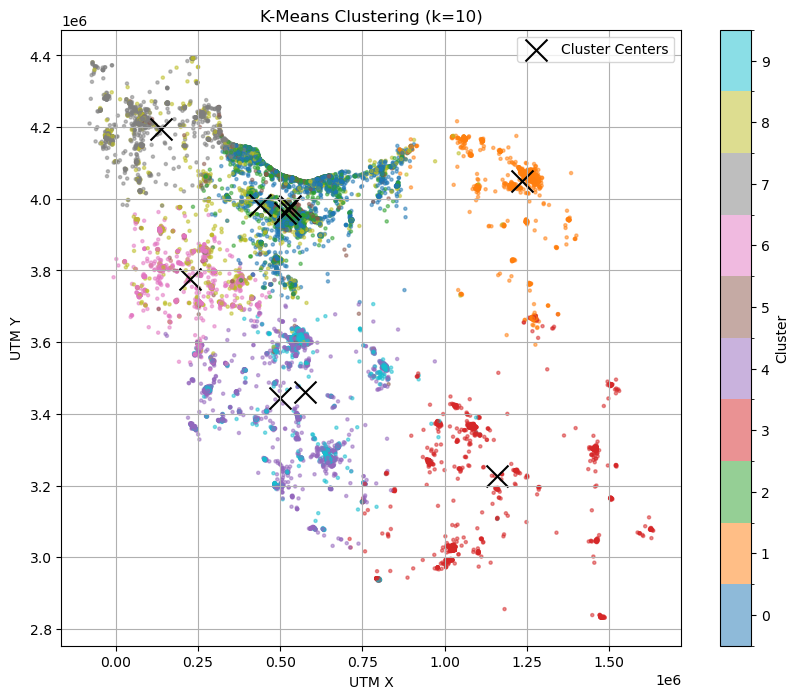

In [89]:
plot_kmeans_clusters(
    df=df_rec,
    centers_df=centers_10_df,
    cluster_col_name="cluster_kmeans_10",
    title="K-Means Clustering (k=10)",
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap_name="tab10"
)

In [90]:
centers_10_df

,utm_x,utm_y,log_price,center_price
0,528939.37,3981118.07,21.28,1.747239e+09
1,1234828.93,4048441.41,21.65,2.531571e+09
2,523031.50,3971312.62,22.37,5.188788e+09
3,1157765.61,3226122.07,21.26,1.709651e+09
4,499237.58,3444829.51,20.85,1.139329e+09
5,516144.98,3959591.94,23.75,2.066472e+10
6,225278.82,3777283.64,21.70,2.646932e+09
7,138618.46,4194435.16,21.75,2.782443e+09
8,438138.30,3983623.83,19.83,4.102552e+08
9,575425.66,3462189.31,22.48,5.776103e+09


In [91]:
wcss = []

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    print(k, kmeans.inertia_)

1 1031891.9999999956
2 761483.4169189075
3 574123.5564326053
4 418843.93162138795
5 364889.5739749131
6 314029.360548713
7 271219.788664959
8 246784.29369284798
9 225829.97502437647
10 206299.80997833292
11 190845.8012377235
12 177047.9219467475
13 164417.82403949587
14 154602.51360476148
15 148577.5343367004
16 139070.9670473858
17 133156.21421709523
18 127389.37202416416
19 121623.60700851792
20 116543.20253628152


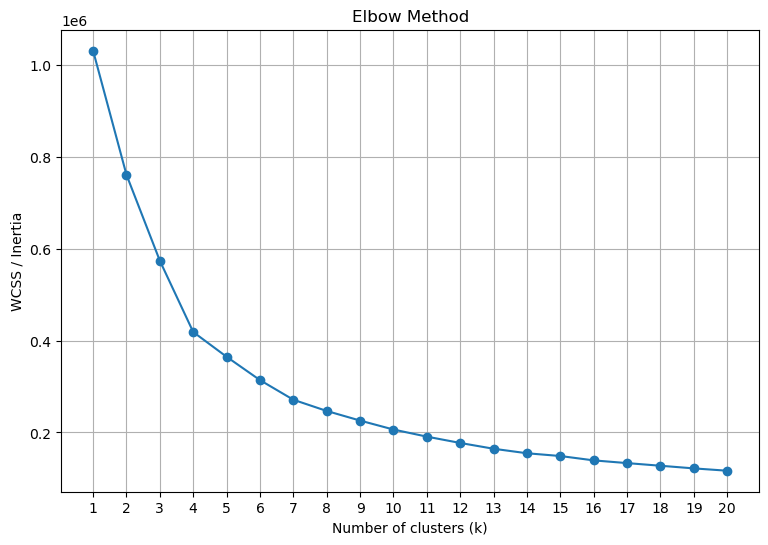

In [92]:
plt.figure(figsize=(9, 6))

plt.plot(list(K_RANGE), wcss, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.xticks(list(K_RANGE))
plt.grid(True)
plt.show()

In [93]:
sample_df = df_rec.sample(n=SCORE_SAMPLE_SIZE, random_state=RANDOM_STATE)

X_sample = sample_df[feature_cols].copy()

sample_scaler = StandardScaler()

X_sample_scaled = sample_scaler.fit_transform(X_sample)

silhouette_scores = []

for k in K_RANGE_SIL:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample_scaled)
    score = silhouette_score(X_sample_scaled, labels)
    
    silhouette_scores.append(score)
    print(k, score)

2 0.39772030212583975
3 0.43869837467712003
4 0.3503261971611395
5 0.35765078085174257
6 0.3700695680013726
7 0.337635176034022
8 0.34100855711500055
9 0.36095694516472987
10 0.35459348185574374
11 0.34890050723772115
12 0.3554551740842163
13 0.3419251228438127
14 0.3455767073699746
15 0.3546245711473783
16 0.36071588168325563
17 0.3685951300338469
18 0.3456030847257197
19 0.36617088368777057
20 0.346890812445009


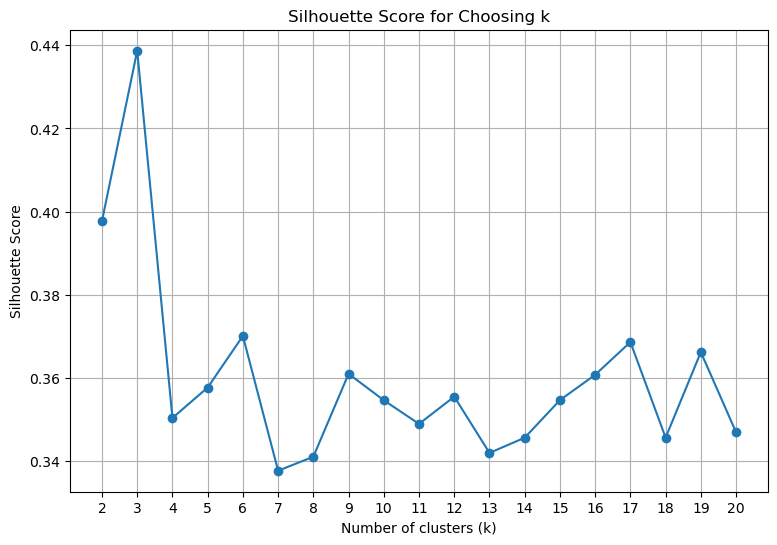

In [94]:
plt.figure(figsize=(9, 6))

plt.plot(list(K_RANGE_SIL), silhouette_scores, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Choosing k")
plt.xticks(list(K_RANGE_SIL))
plt.grid(True)
plt.show()

In [95]:
sample_df = df_rec.sample(n=SCORE_SAMPLE_SIZE, random_state=RANDOM_STATE)

X_sample = sample_df[feature_cols].copy()

sample_scaler = StandardScaler()
X_sample_scaled = sample_scaler.fit_transform(X_sample)

results = []

for k in range(2, 21):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_sample_scaled, labels)
    calinski = calinski_harabasz_score(X_sample_scaled, labels)
    davies = davies_bouldin_score(X_sample_scaled, labels)
    
    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

k_results = pd.DataFrame(results)
k_results

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,44165.606336,0.397720,7169.746569,1.161663
1,3,33435.946034,0.438698,7943.581459,0.967547
2,4,24450.470590,0.350326,9690.999225,0.923840
3,5,21326.815816,0.357651,9064.579253,0.979080
4,6,18337.408557,0.370070,9085.277299,1.016065
5,7,15849.458602,0.337635,9282.237843,0.946566
6,8,14379.791110,0.341009,9060.752560,0.975499
7,9,13113.216509,0.360957,8935.070792,0.939098
8,10,11944.409190,0.354593,8936.256478,0.951262
9,11,11077.249167,0.348901,8828.252816,0.945727


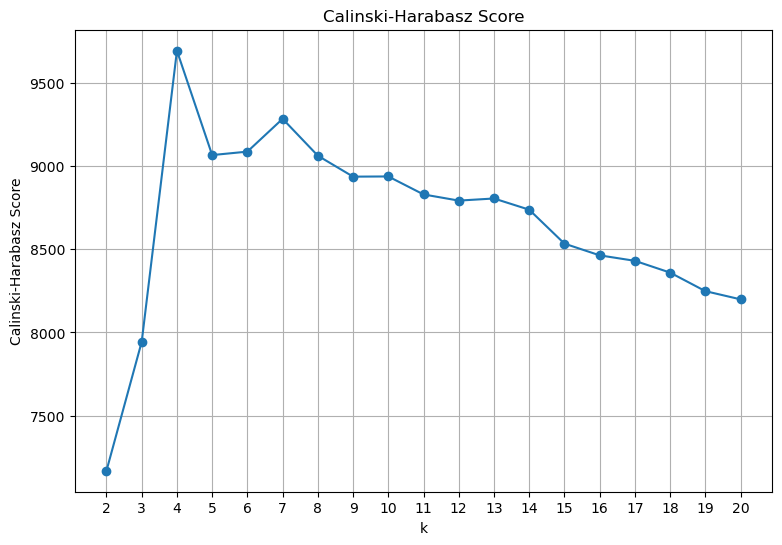

In [96]:
plt.figure(figsize=(9, 6))
plt.plot(k_results["k"], k_results["calinski_harabasz"], marker="o")
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score")
plt.xticks(k_results["k"])
plt.grid(True)
plt.show()

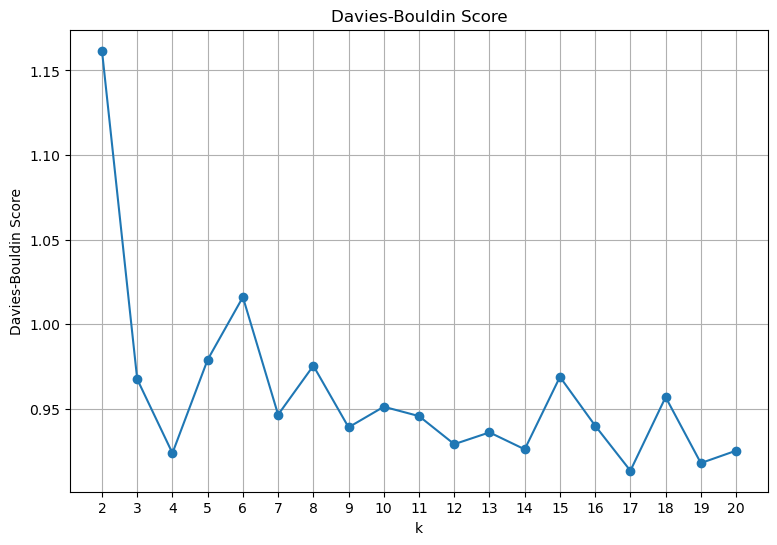

In [97]:
plt.figure(figsize=(9, 6))
plt.plot(k_results["k"], k_results["davies_bouldin"], marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score")
plt.xticks(k_results["k"])
plt.grid(True)
plt.show()

In [98]:
BEST_K = 6

In [99]:
kmeans_best, centers_best_df, counts_best = run_kmeans_clustering(
    df=df_rec,
    X_scaled=X_scaled,
    scaler=scaler,
    feature_cols=feature_cols,
    bool_cols=bool_cols,
    n_clusters=BEST_K,
    cluster_col_name="cluster_kmeans_best",
    random_state=RANDOM_STATE
)

counts_best

cluster_kmeans_best
0    125565
1     26888
2     11588
3     91156
4     41773
5     46994
Name: count, dtype: int64

In [100]:
centers_best_df

,utm_x,utm_y,log_price,center_price
0,520869.40,3960409.05,21.22,1.648709e+09
1,1228929.28,4048547.78,21.65,2.537237e+09
2,1125990.67,3216778.61,21.33,1.825358e+09
3,511595.96,3953183.90,23.02,9.939213e+09
4,181868.61,4108291.93,21.58,2.351264e+09
5,519556.06,3468265.75,21.75,2.788183e+09


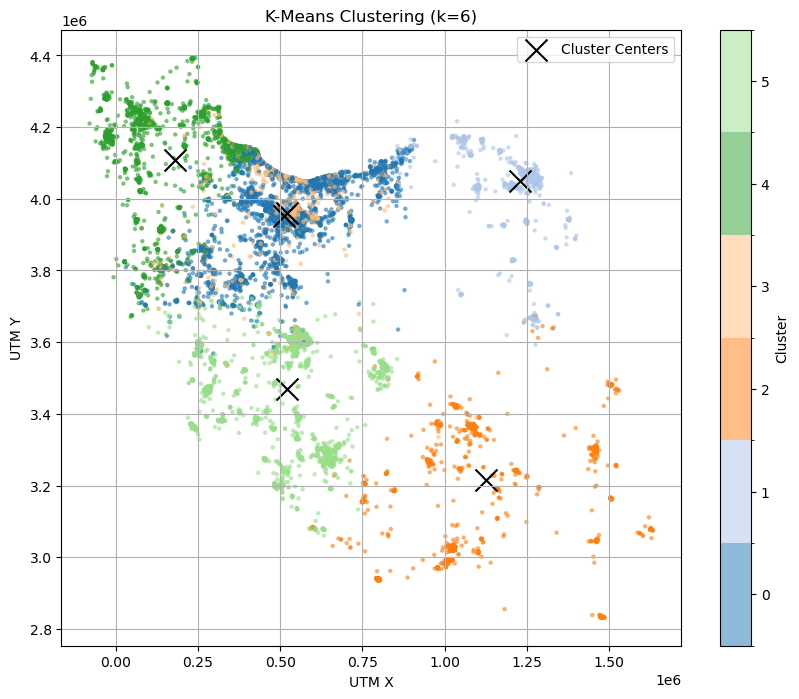

In [101]:
plot_kmeans_clusters(
    df=df_rec,
    centers_df=centers_best_df,
    cluster_col_name="cluster_kmeans_best",
    title=f"K-Means Clustering (k={BEST_K})",
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap_name="tab20"
)

In [102]:
def summarize_clusters(df, cluster_col_name, feature_cols):
    agg_dict = {
        "count": ("price_value", "count")
    }

    if "price_value" in df.columns:
        agg_dict["mean_price"] = ("price_value", "mean")
        agg_dict["median_price"] = ("price_value", "median")

    for col in feature_cols:
        if col == "log_price":
            continue
        
        if col in df.columns:
            agg_dict[f"mean_{col}"] = (col, "mean")

    summary = df.groupby(cluster_col_name).agg(**agg_dict)

    if "mean_price" in summary.columns:
        summary["mean_price_billion"] = summary["mean_price"] / 1e9

    if "median_price" in summary.columns:
        summary["median_price_billion"] = summary["median_price"] / 1e9

    return summary.round(2)

In [103]:
summary_10 = summarize_clusters(df_rec, "cluster_kmeans_10", feature_cols)
summary_10

,count,mean_price,median_price,mean_utm_x,mean_utm_y,mean_price_billion,median_price_billion
cluster_kmeans_10,,,,,,,
0,86932,1.856641e+09,1.800000e+09,528666.32,3981267.89,1.86,1.80
1,26251,4.188224e+09,2.650000e+09,1234809.79,4048460.24,4.19,2.65
2,78563,5.525203e+09,5.000000e+09,522920.60,3971447.23,5.53,5.00
3,10605,2.861302e+09,1.920000e+09,1157765.61,3226122.07,2.86,1.92
4,19525,1.367644e+09,1.350000e+09,499086.91,3444970.90,1.37,1.35
5,33903,2.579297e+10,1.720000e+10,516194.35,3959558.94,25.79,17.20
6,18699,3.232312e+09,2.684500e+09,225223.89,3777369.63,3.23,2.68
7,24047,3.690757e+09,2.800000e+09,137044.35,4194912.09,3.69,2.80
8,18103,4.761163e+08,4.900000e+08,438679.48,3983410.53,0.48,0.49


In [104]:
summary_best = summarize_clusters(df_rec, "cluster_kmeans_best", feature_cols)
summary_best

,count,mean_price,median_price,mean_utm_x,mean_utm_y,mean_price_billion,median_price_billion
cluster_kmeans_best,,,,,,,
0,125565,1.975855e+09,1.900000e+09,520874.08,3960425.48,1.98,1.90
1,26888,4.429214e+09,2.650000e+09,1228936.41,4048504.46,4.43,2.65
2,11588,3.735913e+09,2.000000e+09,1127124.11,3216386.68,3.74,2.00
3,91156,1.383268e+10,8.400000e+09,511598.27,3953096.24,13.83,8.40
4,41773,3.114133e+09,2.500000e+09,181857.81,4108275.39,3.11,2.50
5,46994,4.279150e+09,3.000000e+09,519656.04,3468116.81,4.28,3.00


In [105]:
dbscan_cols = [
    "utm_x",
    "utm_y",
    "log_price"
]

df_dbscan = df_rec[dbscan_cols].copy()

In [106]:
print(df_dbscan.shape)
print(df_dbscan.isna().sum())
df_dbscan.head()

(343964, 3)
utm_x        0
utm_y        0
log_price    0
dtype: int64


,utm_x,utm_y,log_price
2,5.457116e+05,3.954101e+06,22.886589
3,4.814371e+05,3.952066e+06,20.292483
4,5.684670e+05,3.959664e+06,21.678777
6,1.266003e+06,4.053542e+06,23.287446
7,5.379740e+05,3.592362e+06,20.560747


In [107]:
dbscan_scaler = StandardScaler()

In [108]:
df_dbscan_sample = df_dbscan.sample( 
    n=DBSCAN_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).copy()

X_dbscan_sample = dbscan_scaler.fit_transform(df_dbscan_sample)

In [109]:
def eval_dbscan(X_scaled, eps, min_samples):
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    unique_labels = set(labels)
    
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)
    
    return {
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_ratio": noise_ratio
    }

In [110]:
def summarize_dbscan_clusters(df, cluster_col_name):
    summary = df.groupby(cluster_col_name).agg(
        count=("log_price", "count"),
        mean_utm_x=("utm_x", "mean"),
        mean_utm_y=("utm_y", "mean"),
        mean_log_price=("log_price", "mean"),
        median_log_price=("log_price", "median")
    )
    
    summary["mean_price"] = np.expm1(summary["mean_log_price"])
    summary["median_price"] = np.expm1(summary["median_log_price"])
    
    summary["mean_price_billion"] = summary["mean_price"] / 1e9
    summary["median_price_billion"] = summary["median_price"] / 1e9
    
    return summary.round(2)

In [111]:
def plot_dbscan_clusters(
    df,
    cluster_col_name,
    title,
    x_col="utm_x",
    y_col="utm_y",
    sample_size=None,
    random_state=RANDOM_STATE,
    cmap_name="tab10"
):
    if sample_size is not None and len(df) > sample_size:
        plot_df = df.sample(n=sample_size, random_state=random_state)
    else:
        plot_df = df.copy()
    
    labels = sorted(plot_df[cluster_col_name].unique())
    
    base_cmap = plt.get_cmap(cmap_name)
    colors = [base_cmap(i) for i in range(len(labels))]
    
    cmap = ListedColormap(colors)
    
    bounds = np.arange(len(labels) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)
    
    label_to_index = {label: i for i, label in enumerate(labels)}
    color_values = plot_df[cluster_col_name].map(label_to_index)
    
    plt.figure(figsize=(10, 8))
    
    scatter = plt.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=color_values,
        s=5,
        alpha=0.5,
        cmap=cmap,
        norm=norm
    )
    
    cbar = plt.colorbar(
        scatter,
        ticks=range(len(labels))
    )
    
    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Cluster")
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [112]:
dbscan_results = []

eps_values = [0.4, 0.42, 0.45, 0.47, 0.5, 0.52, 0.55, 0.57]
min_samples_values = [100, 200, 300, 400, 500, 1000]

for eps in eps_values:
    for min_samples in min_samples_values:
        result = eval_dbscan(
            X_dbscan_sample,
            eps=eps,
            min_samples=min_samples
        )

        dbscan_results.append(result)

dbscan_results_df = pd.DataFrame(dbscan_results)


dbscan_results_df.sort_values(
    ["n_clusters", "noise_ratio"]
)

,eps,min_samples,n_clusters,n_noise,noise_ratio
43,0.57,200,2,2185,0.04370
44,0.57,300,2,3498,0.06996
38,0.55,300,2,3660,0.07320
45,0.57,400,2,3946,0.07892
41,0.55,1000,2,13161,0.26322
42,0.57,100,3,1020,0.02040
36,0.55,100,3,1123,0.02246
30,0.52,100,3,1318,0.02636
24,0.50,100,3,1492,0.02984
37,0.55,200,3,2389,0.04778


In [113]:
dbscan_results_cluster3_df = dbscan_results_df[
    dbscan_results_df["n_clusters"] == 3
].sort_values("noise_ratio")

dbscan_results_cluster3_df

,eps,min_samples,n_clusters,n_noise,noise_ratio
42,0.57,100,3,1020,0.02040
36,0.55,100,3,1123,0.02246
30,0.52,100,3,1318,0.02636
24,0.50,100,3,1492,0.02984
37,0.55,200,3,2389,0.04778
31,0.52,200,3,2962,0.05924
32,0.52,300,3,4023,0.08046
39,0.55,400,3,4224,0.08448
26,0.50,300,3,4247,0.08494
13,0.45,200,3,4324,0.08648


In [114]:
DBSCAN_EPS = 0.55
DBSCAN_MIN_SAMPLES = 400

dbscan_best = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES
)

df_dbscan_sample["cluster_dbscan"] = dbscan_best.fit_predict(X_dbscan_sample)

df_dbscan_sample["cluster_dbscan"].value_counts().sort_index()

cluster_dbscan
-1     4224
 0    40457
 1     3484
 2     1835
Name: count, dtype: int64

In [115]:
summary_dbscan = summarize_dbscan_clusters(
    df_dbscan_sample, 
    "cluster_dbscan"
)

summary_dbscan

,count,mean_utm_x,mean_utm_y,mean_log_price,median_log_price,mean_price,median_price,mean_price_billion,median_price_billion
cluster_dbscan,,,,,,,,,
-1,4224,786557.15,3521257.84,21.06,20.83,1.403890e+09,1.111111e+09,1.40,1.11
0,40457,466662.98,3941897.82,21.93,21.84,3.342870e+09,3.050000e+09,3.34,3.05
1,3484,1241324.11,4058907.51,21.69,21.73,2.636574e+09,2.730000e+09,2.64,2.73
2,1835,627342.44,3273526.75,22.03,22.00,3.684186e+09,3.600000e+09,3.68,3.60


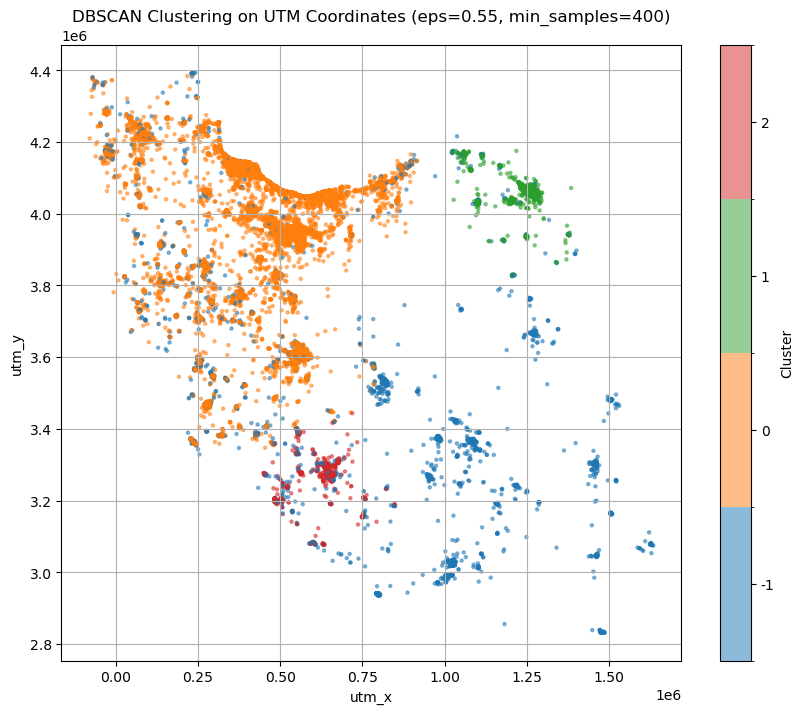

In [116]:
plot_dbscan_clusters(
    df=df_dbscan_sample,
    cluster_col_name="cluster_dbscan",
    title=f"DBSCAN Clustering on UTM Coordinates (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})",
    x_col="utm_x",
    y_col="utm_y",
)